In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("teejmahal20/airline-passenger-satisfaction")

print("Path to dataset files:", path)

100%|██████████| 2.71M/2.71M [00:00<00:00, 3.17MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/teejmahal20/airline-passenger-satisfaction/versions/1


In [ ]:
import os
import pandas as pd

# This is the path you already got from kagglehub
print(path)          # just to verify
print(os.listdir(path))  # see what files are inside

/root/.cache/kagglehub/datasets/teejmahal20/airline-passenger-satisfaction/versions/1
['test.csv', 'train.csv']


In [ ]:
train_df = pd.read_csv(path + "/train.csv")
test_df  = pd.read_csv(path + "/test.csv")   # if you need it

# Look at the first few rows
train_df.head(30)

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied
5,5,111157,Female,Loyal Customer,26,Personal Travel,Eco,1180,3,4,...,1,3,4,4,4,4,1,0,0.0,neutral or dissatisfied
6,6,82113,Male,Loyal Customer,47,Personal Travel,Eco,1276,2,4,...,2,3,3,4,3,5,2,9,23.0,neutral or dissatisfied
7,7,96462,Female,Loyal Customer,52,Business travel,Business,2035,4,3,...,5,5,5,5,4,5,4,4,0.0,satisfied
8,8,79485,Female,Loyal Customer,41,Business travel,Business,853,1,2,...,1,1,2,1,4,1,2,0,0.0,neutral or dissatisfied
9,9,65725,Male,disloyal Customer,20,Business travel,Eco,1061,3,3,...,2,2,3,4,4,3,2,0,0.0,neutral or dissatisfied


## **Cleaning, encoding and preparing data**


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Load dataset
df = train_df.copy()

# 2. Select relevant (selected) columns
selected_features = [
    "Seat comfort",
    "Inflight service",
    "Cleanliness",
    "Online boarding",
    "On-board service"
]

target = "satisfaction"

df = df[selected_features + [target]]


# 3. Drop missing values (simple cleaning)
df = df.dropna()


# 4. Convert Satisfaction (object) → integer
# values "satisfied" and "neutral or dissatisfied"
df[target] = df[target].map({
    "satisfied": 1,
    "neutral or dissatisfied": 0
})

# Verify encoding worked:
print(df[target].value_counts())



satisfaction
0    58879
1    45025
Name: count, dtype: int64


#** Train/Test Split**

In [ ]:
# 5. Train/Test split
# -------------------------------
X = df[selected_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)

Shape of X_train: (83123, 5)
Shape of X_test: (20781, 5)


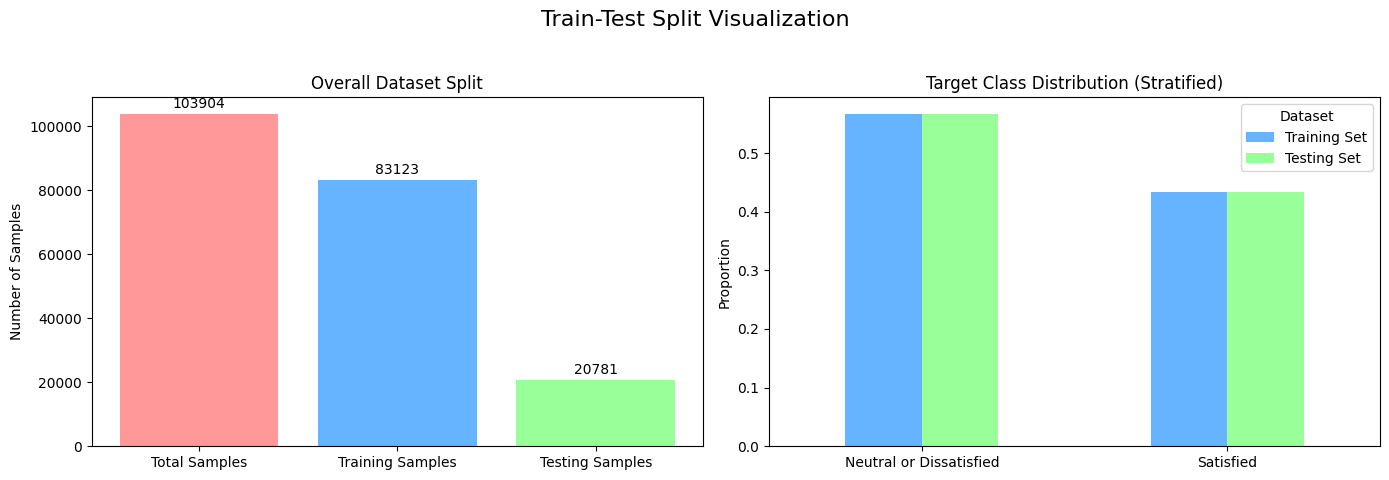

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get sizes of the datasets
total_samples = len(df)
train_samples = len(X_train)
test_samples = len(X_test)

# Get class distributions in y_train and y_test
y_train_counts = y_train.value_counts(normalize=True).sort_index()
y_test_counts = y_test.value_counts(normalize=True).sort_index()

# Create a figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Train-Test Split Visualization', fontsize=16)

# Plot 1: Dataset sizes
labels = ['Total Samples', 'Training Samples', 'Testing Samples']
sizes = [total_samples, train_samples, test_samples]
colors = ['#ff9999', '#66b3ff', '#99ff99']

axes[0].bar(labels, sizes, color=colors)
axes[0].set_ylabel('Number of Samples')
axes[0].set_title('Overall Dataset Split')
for i, size in enumerate(sizes):
    axes[0].text(i, size + 1000, str(size), ha='center', va='bottom')

# Plot 2: Class distribution in Train vs. Test (normalized)
# Combine for easier plotting, and ensure the labels are consistent
y_split_df = pd.DataFrame({
    'Training Set': y_train_counts,
    'Testing Set': y_test_counts
})
y_split_df.index = ['Neutral or Dissatisfied', 'Satisfied']

y_split_df.plot(kind='bar', ax=axes[1], color=['#66b3ff', '#99ff99'])
axes[1].set_ylabel('Proportion')
axes[1].set_title('Target Class Distribution (Stratified)')
axes[1].set_xticklabels(y_split_df.index, rotation=0)
axes[1].legend(title='Dataset')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# **Logistic Regression**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Logistic Regression pipeline
log_reg_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("log_reg", LogisticRegression(max_iter=1000, random_state=42))
])

# Train model
log_reg_clf.fit(X_train, y_train)

# Training accuracy
train_acc_lr = log_reg_clf.score(X_train, y_train)

# Test accuracy
test_acc_lr = log_reg_clf.score(X_test, y_test)

print("=== Logistic Regression Accuracies ===")
print("Training Accuracy :", train_acc_lr)
print("Test Accuracy     :", test_acc_lr)

=== Logistic Regression Accuracies ===
Training Accuracy : 0.8022809571358108
Test Accuracy     : 0.8039555363072037


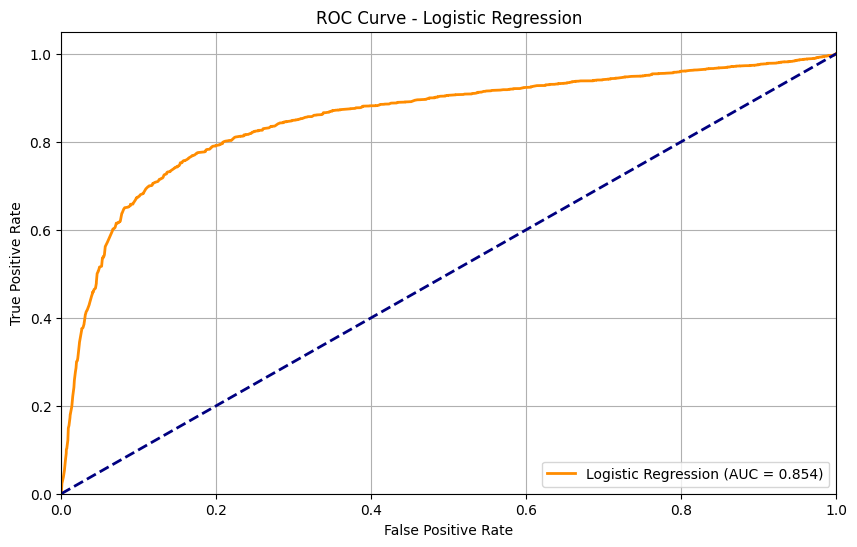

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Get predicted probabilities for the positive class
y_pred_proba_lr = log_reg_clf.predict_proba(X_test)[:, 1]

# 2. Calculate ROC curve values
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_pred_proba_lr)

# 3. Calculate AUC
roc_auc_lr = auc(fpr_lr, tpr_lr)

# 4. Plot ROC Curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_lr, tpr_lr, color='darkorange', lw=2,
         label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')

# Random baseline
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# **Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest model
rf_clf = RandomForestClassifier(
    n_estimators=50,
    random_state=42
)

# Train model
rf_clf.fit(X_train, y_train)

# Training accuracy
train_acc_rf = rf_clf.score(X_train, y_train)

# Test accuracy
test_acc_rf = rf_clf.score(X_test, y_test)

print("=== Random Forest Accuracies ===")
print("Training Accuracy :", train_acc_rf)
print("Test Accuracy     :", test_acc_rf)

=== Random Forest Accuracies ===
Training Accuracy : 0.8479361909459475
Test Accuracy     : 0.8422116356286993


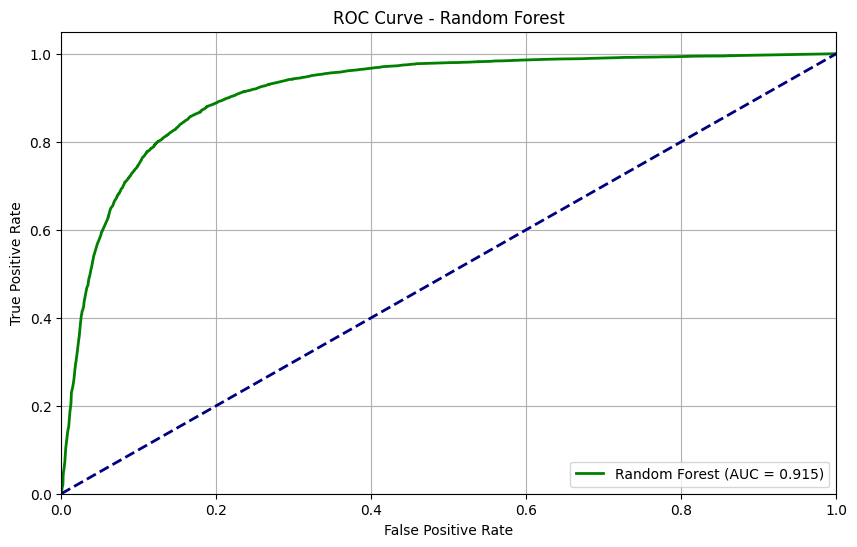

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Get predicted probabilities for the positive class
y_pred_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

# 2. Calculate ROC curve values
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)

# 3. Calculate AUC
roc_auc_rf = auc(fpr_rf, tpr_rf)

# 4. Plot ROC Curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_rf, tpr_rf, color='green', lw=2,
         label=f'Random Forest (AUC = {roc_auc_rf:.3f})')

# Random baseline line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


# **AUC both Logistic Regression and Random Forest**

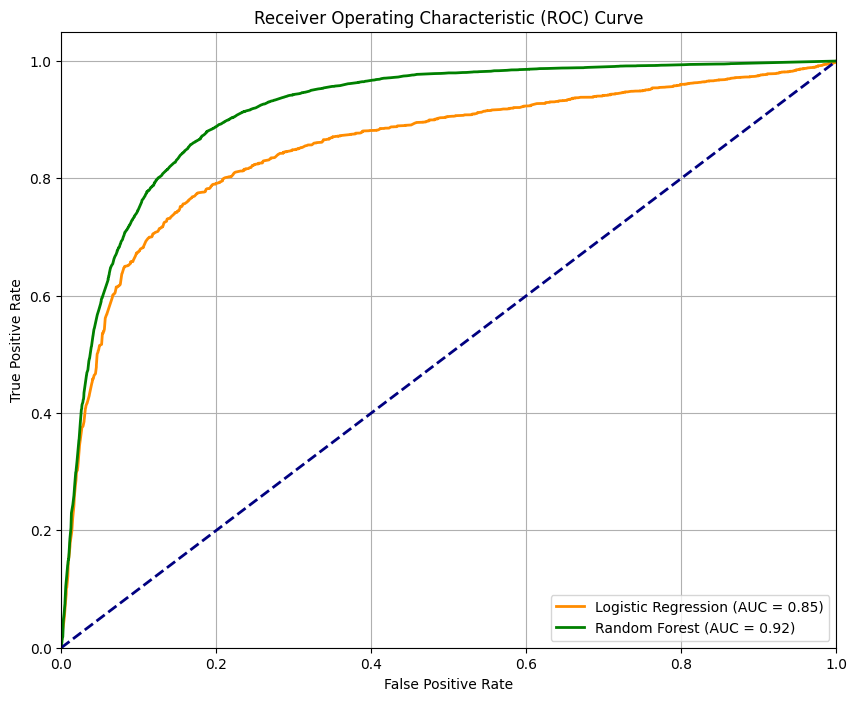

In [ ]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt

# Get predicted probabilities for Logistic Regression
y_pred_proba_lr = log_reg_clf.predict_proba(X_test)[:, 1]

# Get predicted probabilities for Random Forest
y_pred_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# Calculate ROC curve and AUC for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

This ROC curve visualizes the performance of both models across all possible classification thresholds. The closer the curve is to the top-left corner, and the higher the AUC score, the better the model's performance in distinguishing between the two classes (satisfied vs. neutral/dissatisfied).

In [ ]:
import joblib

# Save both models
joblib.dump(log_reg_clf, "logistic_regression_model.pkl")
joblib.dump(rf_clf, "random_forest_model.pkl")

['random_forest_model.pkl']

In [ ]:
from google.colab import files

files.download("logistic_regression_model.pkl")
files.download("random_forest_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>